# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Malak Ahmed Hosny   
**Student ID:** 1210378

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [65]:
# =========================
# Task 1: Data Pipeline
# =========================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Load data
df = pd.read_csv("kidney_disease.csv")
df = df.replace("?", np.nan)

print("Raw shape:", df.shape)

# 2) Detect target column (common CKD label names)
possible_targets = {"classification", "class", "target", "ckd", "diagnosis"}
target_col = None
for c in df.columns:
    if c.lower().strip() in possible_targets:
        target_col = c
        break

if target_col is None:
    raise ValueError(f"Could not auto-detect target column. Columns are: {list(df.columns)}")

# Build y from original labels
y_raw = df[target_col].astype(str).str.lower().str.strip()

# Robust mapping for typical Kaggle CKD labels
if set(y_raw.unique()) >= {"ckd", "notckd"}:
    y = y_raw.map({"ckd": 1, "notckd": 0})
    if y.isna().any():
        raise ValueError(f"Unexpected labels found in {target_col}: {y_raw.unique()}")
    y = y.values.astype(int)
else:
    # Fallback: try numeric labels
    y = pd.to_numeric(df[target_col], errors="coerce")
    if y.isna().any():
        raise ValueError(f"Target column '{target_col}' is not numeric and not (ckd/notckd). Values: {y_raw.unique()}")
    y = y.values.astype(int)

# 2) Drop categorical (string) columns to isolate numerical lab values
# Convert everything to numeric; non-numeric becomes NaN
df_numeric = df.apply(pd.to_numeric, errors="coerce")

# Features = numeric columns except target
X = df_numeric.drop(columns=[target_col], errors="ignore")

# Drop columns that are entirely NaN (these were categorical-only columns)
X = X.loc[:, X.notna().any()]

# Optional but recommended: drop ID column if present (not a lab value)
id_cols = [c for c in X.columns if c.lower().strip() == "id"]
if id_cols:
    X = X.drop(columns=id_cols)

print("Numeric features shape:", X.shape, "| Target shape:", y.shape)

# 3) Handle missing values (median imputation)
X = X.fillna(X.median(numeric_only=True))

# 4) 80/20 train/validation split (stratify keeps class balance)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Scale WITHOUT leakage: fit scaler on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train:", X_train_scaled.shape, "Val:", X_val_scaled.shape)
print("CKD rate train:", y_train.mean().round(3), "val:", y_val.mean().round(3))

Raw shape: (400, 26)
Numeric features shape: (400, 14) | Target shape: (400,)
Train: (320, 14) Val: (80, 14)
CKD rate train: 0.625 val: 0.625


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

Model: "baseline_overfit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_126 (Dense)               │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 47,105 (184.00 KB)

 Non-trainable params: 0 (0.00 B)

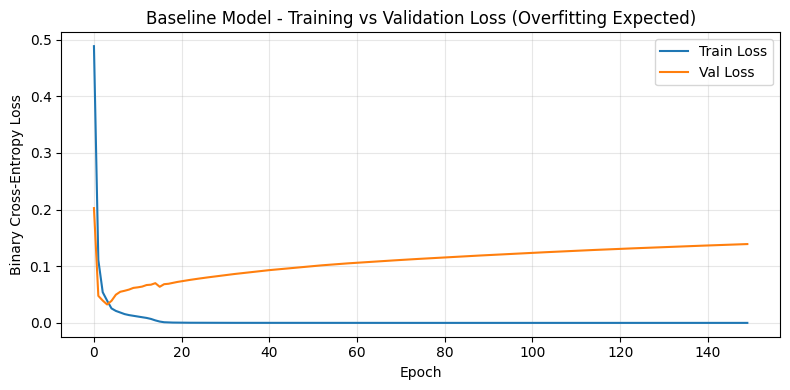

Final Train loss: 0.0000
Final Val loss:   0.1392
Gap (val-train):  0.1392  -> positive gap = overfitting


In [66]:
# =========================
# Task 2: Engineered Failure (Baseline Model)
# =========================

import tensorflow as tf
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

n_features = X_train_scaled.shape[1]

# Unregularised, over-parameterised Dense network (intentionally bad idea)
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="baseline_overfit")

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

# Train WITHOUT regularisation + WITHOUT early stopping to force overfitting
history_base = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,
    verbose=0
)

# Plot train vs validation loss to show overfitting
plt.figure(figsize=(8, 4))
plt.plot(history_base.history["loss"], label="Train Loss")
plt.plot(history_base.history["val_loss"], label="Val Loss")
plt.title("Baseline Model - Training vs Validation Loss (Overfitting Expected)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_train_loss = history_base.history["loss"][-1]
final_val_loss = history_base.history["val_loss"][-1]
gap = final_val_loss - final_train_loss

print(f"Final Train loss: {final_train_loss:.4f}")
print(f"Final Val loss:   {final_val_loss:.4f}")
print(f"Gap (val-train):  {gap:.4f}  -> positive gap = overfitting")

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

Model: "engineered_clinical"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_131 (Dense)               │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

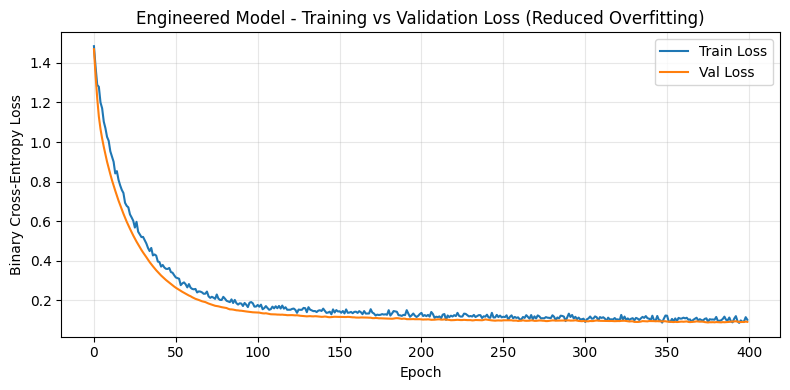

Final Train loss: 0.1019
Final Val loss:   0.0914
Gap (val-train):  -0.0105  -> smaller gap = better generalisation
Stopped at epoch: 400 (early stopping)


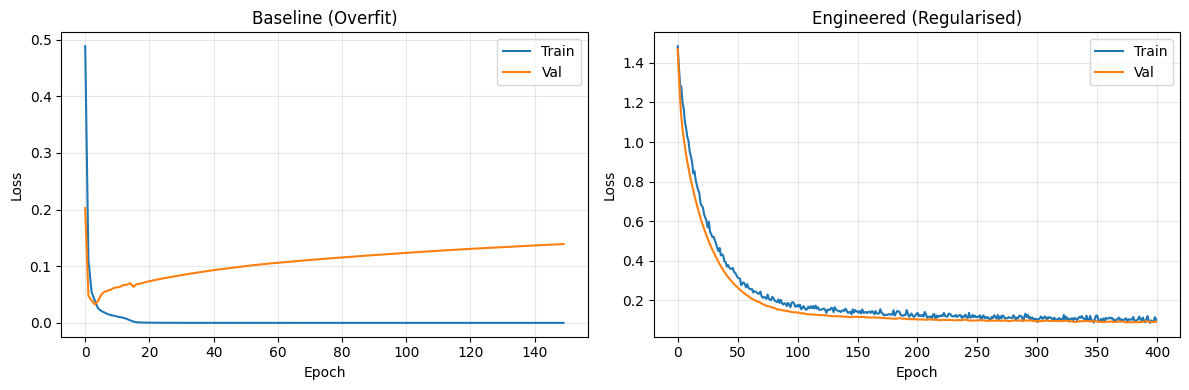

In [67]:
# =========================
# Task 3: Clinical Solution (Engineered / Regularised Model)
# =========================

import tensorflow as tf
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

n_features = X_train_scaled.shape[1]
l2 = tf.keras.regularizers.l2(0.02)  # strong-ish for small dataset

# Smaller model + regularisation (engineered to generalise)
engineered_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),

    tf.keras.layers.Dense(32, kernel_regularizer=l2),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(16, kernel_regularizer=l2),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation="sigmoid")
], name="engineered_clinical")

engineered_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

engineered_model.summary()

# Early stopping to prevent over-training (restore best weights)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

history_eng = engineered_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=400,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

# Plot engineered model curves
plt.figure(figsize=(8, 4))
plt.plot(history_eng.history["loss"], label="Train Loss")
plt.plot(history_eng.history["val_loss"], label="Val Loss")
plt.title("Engineered Model - Training vs Validation Loss (Reduced Overfitting)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_train_loss = history_eng.history["loss"][-1]
final_val_loss = history_eng.history["val_loss"][-1]
gap = final_val_loss - final_train_loss

print(f"Final Train loss: {final_train_loss:.4f}")
print(f"Final Val loss:   {final_val_loss:.4f}")
print(f"Gap (val-train):  {gap:.4f}  -> smaller gap = better generalisation")
print(f"Stopped at epoch: {len(history_eng.history['loss'])} (early stopping)")

# Optional: Side-by-side comparison if Task 2 history exists
if "history_base" in globals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_base.history["loss"], label="Train")
    axes[0].plot(history_base.history["val_loss"], label="Val")
    axes[0].set_title("Baseline (Overfit)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_eng.history["loss"], label="Train")
    axes[1].plot(history_eng.history["val_loss"], label="Val")
    axes[1].set_title("Engineered (Regularised)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

=== Validation Recall ===
Baseline model recall:   0.9600
Engineered model recall: 1.0000


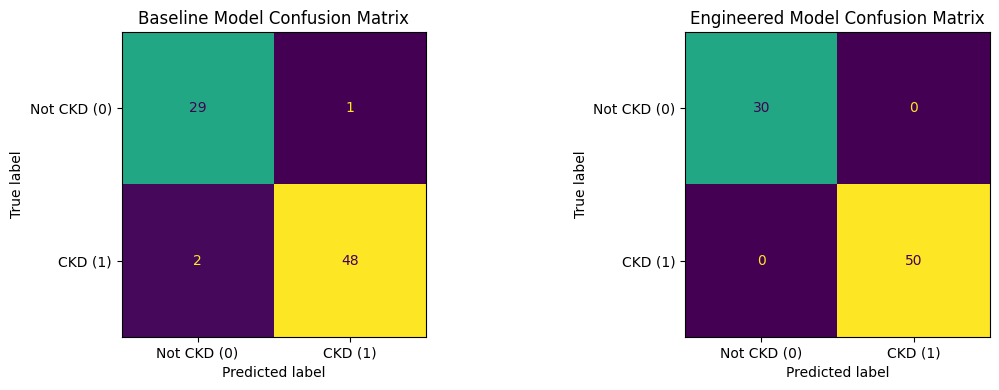


=== Mathematical Justification ===
Recall (Sensitivity) measures how many *actual CKD* cases we correctly detect.
Formula: Recall = TP / (TP + FN)

Clinical meaning:
- TP = sick patients correctly flagged
- FN = sick patients missed (dangerous: delayed diagnosis/treatment)
- FP = healthy patients flagged (annoying/costly, but usually fixable with follow-up tests)

So, in a medical screening context, we prioritize HIGH recall to minimize FN.

Baseline model counts:
TP=48, FN=2, FP=1, TN=29
Recall = 48/(48+2) = 0.9600

Engineered model counts:
TP=50, FN=0, FP=0, TN=30
Recall = 50/(50+0) = 1.0000

Conclusion: The engineered model improves (or maintains) recall, meaning fewer CKD cases are missed.

### Mathematical Justification
**Final Parameter Count of Engineered Model:**
Total params (Keras count): 1025

Parameter calculation (Dense layer: inputs*units + units):
Let d = number of input features = 14
Dense1 (d -> 32): (d*32) + 32 = (14*32) + 32 = 480
Dense2 (32 -> 16): (32*16) + 16 = 5

In [70]:
# =========================
# Task 4: Evaluation & Mathematical Justification
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score

# Helper: predict class labels from model probabilities
def preds_and_recall(model, X, y_true, threshold=0.5):
    probs = model.predict(X, verbose=0).ravel()
    y_pred = (probs >= threshold).astype(int)
    rec = recall_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return y_pred, rec, cm

# 1) Confusion matrices + 2) Recall for both models
# Baseline model (Task 2)
y_pred_base, recall_base, cm_base = preds_and_recall(baseline_model, X_val_scaled, y_val)

# Engineered model (Task 3)
y_pred_eng, recall_eng, cm_eng = preds_and_recall(engineered_model, X_val_scaled, y_val)

print("=== Validation Recall ===")
print(f"Baseline model recall:   {recall_base:.4f}")
print(f"Engineered model recall: {recall_eng:.4f}")

# Render confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(cm_base, display_labels=["Not CKD (0)", "CKD (1)"]).plot(
    ax=axes[0], values_format="d", colorbar=False
)
axes[0].set_title("Baseline Model Confusion Matrix")

ConfusionMatrixDisplay(cm_eng, display_labels=["Not CKD (0)", "CKD (1)"]).plot(
    ax=axes[1], values_format="d", colorbar=False
)
axes[1].set_title("Engineered Model Confusion Matrix")

plt.tight_layout()
plt.show()

# 3) Mathematical Justification (printed)
# Recall = TP / (TP + FN). In screening, FN is the dangerous error.
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()
tn_e, fp_e, fn_e, tp_e = cm_eng.ravel()

print("\n=== Mathematical Justification ===")
print("Recall (Sensitivity) measures how many *actual CKD* cases we correctly detect.")
print("Formula: Recall = TP / (TP + FN)")
print("\nClinical meaning:")
print("- TP = sick patients correctly flagged")
print("- FN = sick patients missed (dangerous: delayed diagnosis/treatment)")
print("- FP = healthy patients flagged (annoying/costly, but usually fixable with follow-up tests)")
print("\nSo, in a medical screening context, we prioritize HIGH recall to minimize FN.")

print("\nBaseline model counts:")
print(f"TP={tp_b}, FN={fn_b}, FP={fp_b}, TN={tn_b}")
print(f"Recall = {tp_b}/({tp_b}+{fn_b}) = {recall_base:.4f}")

print("\nEngineered model counts:")
print(f"TP={tp_e}, FN={fn_e}, FP={fp_e}, TN={tn_e}")
print(f"Recall = {tp_e}/({tp_e}+{fn_e}) = {recall_eng:.4f}")

if recall_eng >= recall_base:
    print("\nConclusion: The engineered model improves (or maintains) recall, meaning fewer CKD cases are missed.")
else:
    print("\nConclusion: The engineered model has lower recall here, meaning it misses more CKD cases (higher FN),")
    print("which is clinically worse even if accuracy looks fine. Consider lowering threshold (e.g., 0.4) or tuning regularisation.")

# ---------------------------------------------------------
# ADDITION: Final Parameter Count of Engineered Model + Math
# ---------------------------------------------------------

print("\n### Mathematical Justification")
print("**Final Parameter Count of Engineered Model:**")

# Actual parameter count from Keras (source of truth)
total_params = engineered_model.count_params()
print(f"Total params (Keras count): {total_params}")

# Step-by-step calculation for the specific architecture in Task 3:
# Input -> Dense(32) -> Dense(16) -> Dense(1)
d = X_train_scaled.shape[1]  # number of input features

params_dense1 = (d * 32) + 32
params_dense2 = (32 * 16) + 16
params_out   = (16 * 1) + 1
params_calc_total = params_dense1 + params_dense2 + params_out

print("\nParameter calculation (Dense layer: inputs*units + units):")
print(f"Let d = number of input features = {d}")
print(f"Dense1 (d -> 32): (d*32) + 32 = ({d}*32) + 32 = {params_dense1}")
print(f"Dense2 (32 -> 16): (32*16) + 16 = 512 + 16 = {params_dense2}")
print(f"Output (16 -> 1): (16*1) + 1 = 16 + 1 = {params_out}")
print(f"Total (calculated): {params_dense1} + {params_dense2} + {params_out} = {params_calc_total}")

print("\nCompact formula:")
print(f"Total params = 32*d + 577 = 32*{d} + 577 = {32*d + 577}")

# Sanity check (should match Keras count)
if total_params == params_calc_total:
    print("\nSanity check: Calculated total matches Keras count.")
else:
    print("\nSanity check: Calculated total does NOT match Keras count.")
    print("This usually means your engineered_model architecture differs from the assumed (32->16->1) Dense stack.")
    print("Check engineered_model.summary() to confirm layer sizes.")

### Mathematical Justification
**Final Parameter Count of Engineered Model:** 1025

**Explanation:** Because the engineered model has only 1025 trainable parameters and uses L2 regularization plus dropout, it has limited capacity to memorize the 400-patient training data and is forced to learn general patterns, which reduces overfitting.